In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from bs4 import BeautifulSoup
from wordcloud import WordCloud
from collections import Counter
from nltk.stem import WordNetLemmatizer

In [20]:
nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [21]:
df = pd.read_csv("/content/emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [22]:
df.shape

(5728, 2)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [24]:
df.isnull().sum()

,0
text,0
spam,0


In [25]:
df.duplicated().sum()

np.int64(33)

In [26]:
df.drop_duplicates(inplace=True)

In [27]:
df.shape

(5695, 2)

In [28]:
target_col = "spam"
text_col = "text"


Class Distribution:
spam
0    4327
1    1368
Name: count, dtype: int64


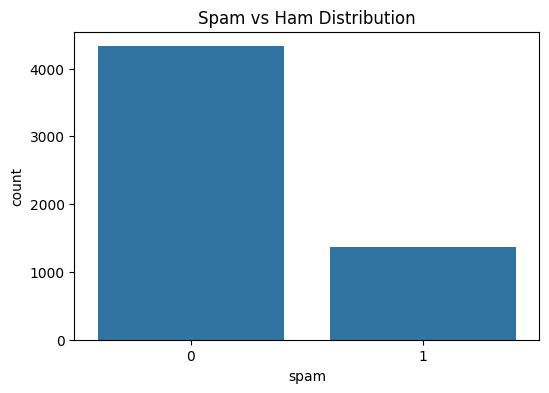

In [29]:
print("\nClass Distribution:")
print(df[target_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df[target_col])
plt.title("Spam vs Ham Distribution")
plt.show()


In [30]:
def clean_text(text):

    text = str(text).lower()

    # remove html
    text = BeautifulSoup(text, "html.parser").get_text()

    # remove urls
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # remove subject
    text = re.sub(r'^subject\s*:\s*', '', text)

    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove extra spaces
    text = ' '.join(text.split())

    # lemmatization
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [31]:
df[text_col] = df[text_col].astype(str)
df["clean_text"] = df[text_col].apply(clean_text)

In [32]:
df["char_count"] = df[text_col].apply(len)
df["word_count"] = df[text_col].apply(lambda x: len(str(x).split()))
df["sentence_count"] = df[text_col].apply(lambda x: len(str(x).split(".")))

In [33]:
print("\nText Statistics:")
print(df[["char_count", "word_count", "sentence_count"]].describe())


Text Statistics:
         char_count   word_count  sentence_count
count   5695.000000  5695.000000     5695.000000
mean    1558.067076   327.079543       17.120105
std     2047.078711   419.598400       27.578434
min       13.000000     2.000000        1.000000
25%      508.500000   101.000000        6.000000
50%      979.000000   210.000000       11.000000
75%     1893.000000   401.000000       20.000000
max    43952.000000  8477.000000     1248.000000


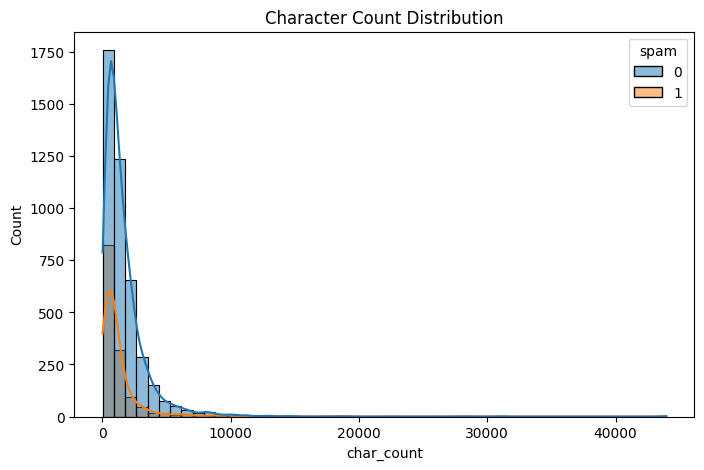

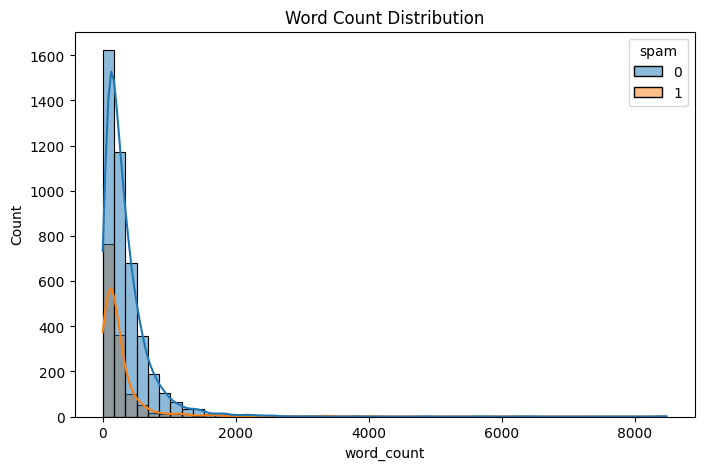

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="char_count", hue=target_col, kde=True, bins=50)
plt.title("Character Count Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="word_count", hue=target_col, kde=True, bins=50)
plt.title("Word Count Distribution")
plt.show()

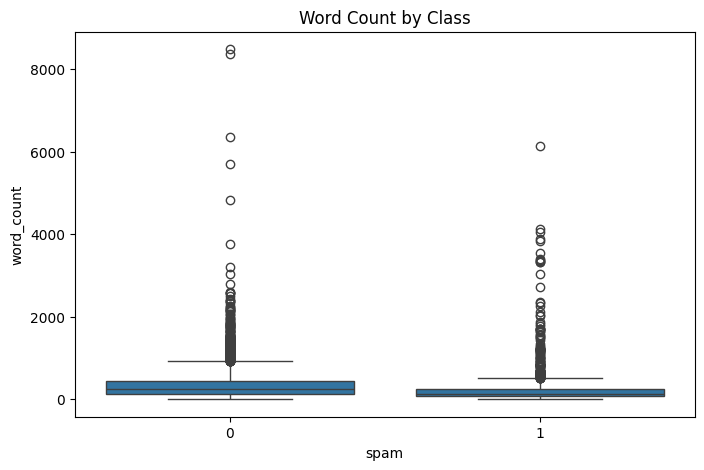

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df[target_col], y=df["word_count"])
plt.title("Word Count by Class")
plt.show()

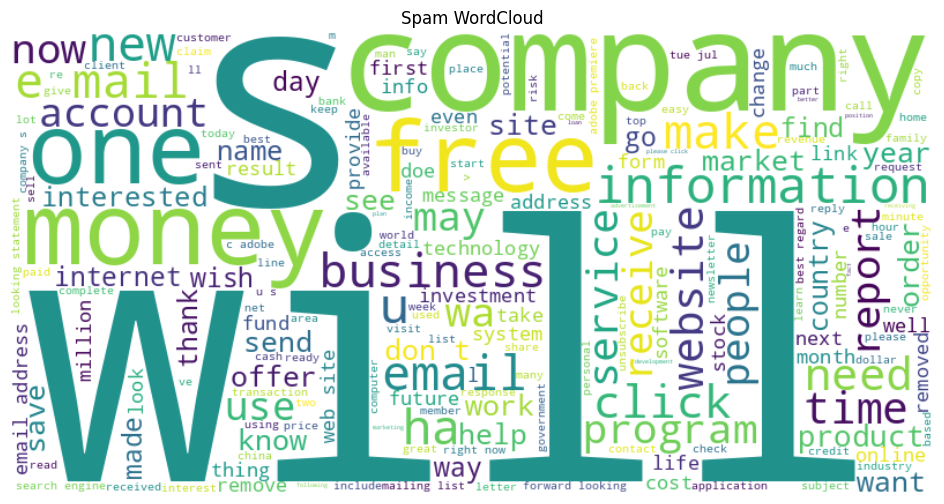

In [36]:
spam_text = " ".join(df[df[target_col] == 1]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()


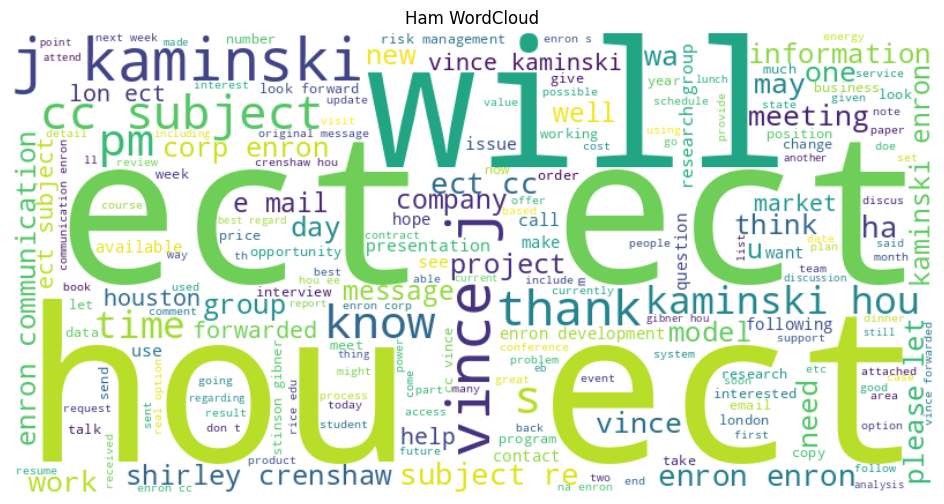

In [37]:
ham_text = " ".join(df[df[target_col] == 0]["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()





Top Spam Words:
    Word  Count
0    the   8975
1     to   8165
2    and   6517
3      a   5897
4     of   5629
5    you   4920
6     in   3880
7   your   3730
8    for   3186
9     is   2977
10  this   2822
11    it   1934
12  that   1896
13     i   1772
14  with   1734
15    we   1724
16    be   1680
17   are   1590
18    or   1588
19    on   1582


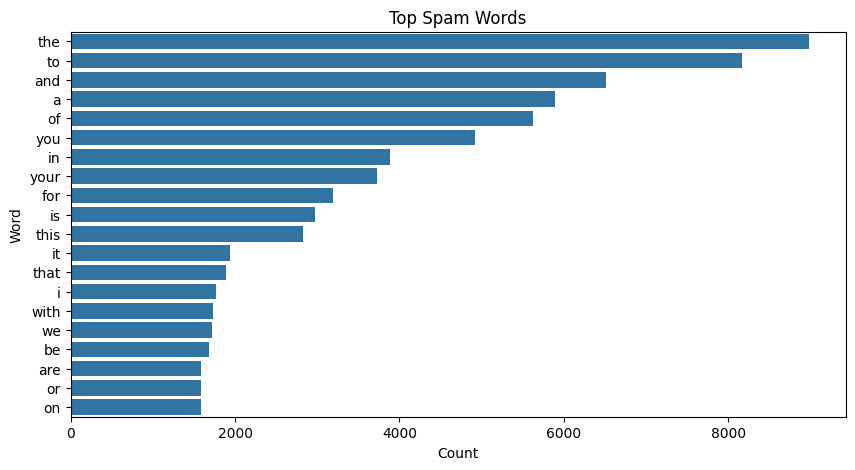


Top Ham Words:
     Word  Count
0     the  40935
1      to  33369
2     and  20805
3       a  20093
4      of  18027
5       i  15510
6     you  14107
7      in  14028
8     for  13452
9   enron  13329
10    ect  11410
11     on  11062
12     is   9567
13  vince   8468
14     be   7527
15   that   7351
16   this   7171
17   with   7076
18     we   6913
19   will   6654


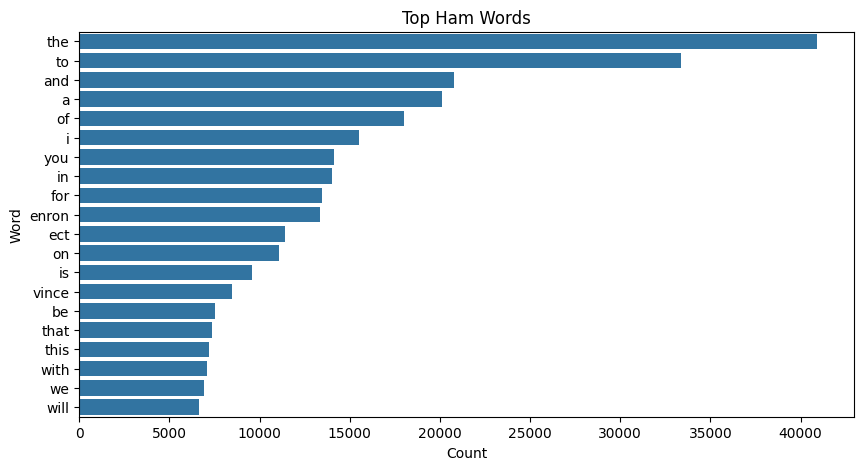

In [38]:
def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()
    common_words = Counter(words).most_common(n)
    return pd.DataFrame(common_words, columns=["Word", "Count"])

print("\nTop Spam Words:")
spam_words = get_top_words(df[df[target_col] == 1]["clean_text"])
print(spam_words)

plt.figure(figsize=(10,5))
sns.barplot(data=spam_words, x="Count", y="Word")
plt.title("Top Spam Words")
plt.show()

print("\nTop Ham Words:")
ham_words = get_top_words(df[df[target_col] == 0]["clean_text"])
print(ham_words)

plt.figure(figsize=(10,5))
sns.barplot(data=ham_words, x="Count", y="Word")
plt.title("Top Ham Words")
plt.show()

In [40]:
df.to_csv("cleaned_emails.csv", index=False)

print("\nEDA Completed Successfully.")


EDA Completed Successfully.
